In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (confusion_matrix, precision_score, recall_score, f1_score,
                              accuracy_score, roc_auc_score, RocCurveDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 0 

In [2]:
cancer_df = pd.read_csv("wdbc_with_headers.csv")
X_full = cancer_df.drop(columns=["ID", "Diagnosis"])
y_full = cancer_df["Diagnosis"].map({"M": 1, "B": 0})  # 1 = malignant

print(f"X_full.shape={X_full.shape}")
print(f"P-hat(malignant)={y_full.mean():.3}")

X_full.shape=(569, 30)
P-hat(malignant)=0.373


In [3]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full)
print(f"y_train mean={y_train.mean():.3}, y_test mean={y_test.mean():.3}")

y_train mean=0.374, y_test mean=0.368


In [4]:
# loop over features, use pandas.corr() to find highly
# correlated pairs, and remove the one less correlated with y
corr_matrix = X_train_raw.corr() 
train_with_y = X_train_raw.copy()
train_with_y["y"] = y_train.values
corr_with_y = train_with_y.corr()["y"].drop("y").abs()

THRESH = 0.90
to_drop = set()
cols = list(X_train_raw.columns)
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        f1, f2 = cols[i], cols[j]
        if f1 in to_drop or f2 in to_drop:
            continue
        if abs(corr_matrix.loc[f1, f2]) > THRESH:
            to_drop.add(f1 if corr_with_y[f1] < corr_with_y[f2] else f2)

print(f"Dropping {len(to_drop)} redundant features (|corr| > {THRESH}): {sorted(to_drop)}")
kept_features = [c for c in cols if c not in to_drop]
print(f"kept_features ({len(kept_features)}): {kept_features}")

X_train = X_train_raw[kept_features]
X_test = X_test_raw[kept_features]

Dropping 10 redundant features (|corr| > 0.9): ['area_mean', 'area_se', 'area_worst', 'concave_points_mean', 'concavity_mean', 'perimeter_mean', 'perimeter_se', 'radius_mean', 'radius_worst', 'texture_mean']
kept_features (20): ['smoothness_mean', 'compactness_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'texture_worst', 'perimeter_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [5]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [6]:
parameters = {"C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10]}

clf_l1 = GridSearchCV(LogisticRegression(penalty="l1", solver="liblinear",
                                          max_iter=5000, random_state=RANDOM_STATE),
                       parameters)
clf_l1.fit(X_train_s, y_train)
print(f"L1: clf.best_score_={clf_l1.best_score_:.3}, clf.best_params_={clf_l1.best_params_}")

clf_l2 = GridSearchCV(LogisticRegression(penalty="l2", solver="liblinear",
                                          max_iter=5000, random_state=RANDOM_STATE),
                       parameters)
clf_l2.fit(X_train_s, y_train)
print(f"L2: clf.best_score_={clf_l2.best_score_:.3}, clf.best_params_={clf_l2.best_params_}")

L1: clf.best_score_=0.982, clf.best_params_={'C': 3}
L2: clf.best_score_=0.98, clf.best_params_={'C': 3}


In [7]:
print(pd.DataFrame(clf_l1.cv_results_)[["params", "mean_test_score", "rank_test_score"]].
      sort_values(by="mean_test_score", ascending=False))

        params  mean_test_score  rank_test_score
5     {'C': 3}         0.982418                1
4     {'C': 1}         0.978022                2
2   {'C': 0.1}         0.973626                3
3   {'C': 0.3}         0.973626                3
6    {'C': 10}         0.962637                5
1  {'C': 0.03}         0.940659                6
0  {'C': 0.01}         0.909890                7


In [8]:
best_l1 = clf_l1.best_estimator_
y_hat = best_l1.predict(X_test_s)

M = confusion_matrix(y_true=y_test, y_pred=y_hat)
df_M = pd.DataFrame(data=M, index=["actual 0", "actual 1"], columns=["pred 0", "pred 1"])
print(f"df_M:\n{df_M}")

TN, FP, FN, TP = M.ravel()
print(f"TN={TN}, FP={FP}, FN={FN}, TP={TP}")

precision = precision_score(y_true=y_test, y_pred=y_hat)
recall = recall_score(y_true=y_test, y_pred=y_hat)
accuracy = accuracy_score(y_true=y_test, y_pred=y_hat)
print(f"precision={precision:.3}, recall={recall:.3}, accuracy={accuracy:.3}")

TPR = TP / (TP + FN) # same as recall
FPR = FP / (FP + TN)
print(f"TPR={TPR:.3}, FPR={FPR:.3}")

f1 = f1_score(y_true=y_test, y_pred=y_hat)
print(f"f1={f1:.3}")

df_M:
          pred 0  pred 1
actual 0      70       2
actual 1       5      37
TN=70, FP=2, FN=5, TP=37
precision=0.949, recall=0.881, accuracy=0.939
TPR=0.881, FPR=0.0278
f1=0.914


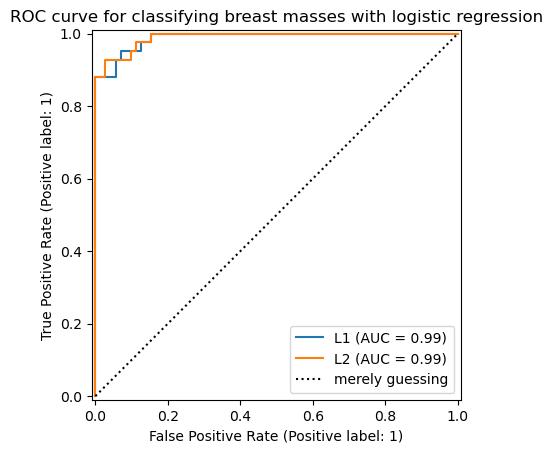

L1 AUC=0.989, L2 AUC=0.99


In [9]:
RocCurveDisplay.from_estimator(clf_l1.best_estimator_, X_test_s, y_test, name="L1")
ax = plt.gca()
RocCurveDisplay.from_estimator(clf_l2.best_estimator_, X_test_s, y_test, name="L2", ax=ax)
plt.plot([0, 1], [0, 1], ":k", label="merely guessing")
plt.title("ROC curve for classifying breast masses with logistic regression")
plt.legend()
plt.savefig("roc_curves_profstyle.png", dpi=150)
plt.show(block=False)

auc_l1 = roc_auc_score(y_true=y_test, y_score=clf_l1.best_estimator_.predict_proba(X_test_s)[:, 1])
auc_l2 = roc_auc_score(y_true=y_test, y_score=clf_l2.best_estimator_.predict_proba(X_test_s)[:, 1])
print(f"L1 AUC={auc_l1:.3}, L2 AUC={auc_l2:.3}")

In [10]:
summary = pd.DataFrame(columns=["model", "best_C", "acc_train", "acc_test", "n_nonzero_coef"])
for name, clf in [("L1", clf_l1), ("L2", clf_l2)]:
    m = clf.best_estimator_
    new_row = pd.DataFrame({
        "model": [f"LogisticRegression(penalty='{name.lower()}')"],
        "best_C": [clf.best_params_["C"]],
        "acc_train": [m.score(X_train_s, y_train)],
        "acc_test": [m.score(X_test_s, y_test)],
        "n_nonzero_coef": [int(np.sum(m.coef_ != 0))],
    })
    summary = pd.concat([summary, new_row])
pd.set_option("display.precision", 3)
print(summary)

                              model best_C  acc_train  acc_test n_nonzero_coef
0  LogisticRegression(penalty='l1')      3      0.987     0.939             14
0  LogisticRegression(penalty='l2')      3      0.991     0.939             20


In [11]:
from scipy import stats

# an unregularized fit hit complete separation, so p-values were estimated via bootstrap resampling instead
n_boot = 1000
rng = np.random.RandomState(RANDOM_STATE)
n = X_train_s.shape[0]
y_train_arr = y_train.values

boot_coefs = np.zeros((n_boot, len(kept_features)))
for b in range(n_boot):
    idx = rng.randint(0, n, n)
    Xb, yb = X_train_s[idx], y_train_arr[idx]
    m = LogisticRegression(penalty="l2", C=1, solver="liblinear", max_iter=2000)
    m.fit(Xb, yb)
    boot_coefs[b] = m.coef_[0]

means = boot_coefs.mean(axis=0)
ses = boot_coefs.std(axis=0)
z_scores = means / ses
pvals = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))

pval_table = pd.DataFrame({
    "coefficient": means.round(3),
    "std_error": ses.round(3),
    "p_value": pvals.round(4)
}, index=kept_features).sort_values("p_value")
print(pval_table)

                         coefficient  std_error  p_value
concave_points_worst           1.414      0.241    0.000
concavity_worst                1.003      0.226    0.000
radius_se                      2.367      0.369    0.000
perimeter_worst                2.635      0.258    0.000
texture_worst                  1.278      0.247    0.000
smoothness_mean                0.688      0.214    0.001
compactness_se                -0.711      0.235    0.002
symmetry_worst                 0.756      0.270    0.005
fractal_dimension_se          -0.518      0.250    0.038
fractal_dimension_mean        -0.601      0.302    0.046
concave_points_se              0.419      0.272    0.124
compactness_mean               0.337      0.263    0.200
smoothness_worst               0.366      0.289    0.205
symmetry_mean                 -0.232      0.250    0.354
compactness_worst              0.131      0.181    0.469
texture_se                    -0.202      0.299    0.499
fractal_dimension_worst        

10 of the 20 features are significant at p < 0.05   
- Strongest predictors by coefficient size: perimiter_worst, raidus_se, concave_points_worst, texture_worst, concavity_worst
- Bottom 10 (concave_points_se through smoothness_se): you can't confidently say they matter

In [12]:
# does dropping the non-significant features hurt accuracy?
# refit using only the 10 features significant at p < 0.05.
significant_features = pval_table[pval_table["p_value"] < 0.05].index.tolist()
print(f"Significant features ({len(significant_features)}): {significant_features}")

X_train_sig = pd.DataFrame(X_train_s, columns=kept_features)[significant_features]
X_test_sig = pd.DataFrame(X_test_s, columns=kept_features)[significant_features]

clf_reduced = GridSearchCV(LogisticRegression(penalty="l2", solver="liblinear",
                                               max_iter=5000, random_state=RANDOM_STATE),
                            parameters)
clf_reduced.fit(X_train_sig, y_train)
m_reduced = clf_reduced.best_estimator_

print(f"Reduced model (10 features): acc_train={m_reduced.score(X_train_sig, y_train):.3}, "
      f"acc_test={m_reduced.score(X_test_sig, y_test):.3}")
print(f"Full model (20 features):    acc_train={summary.iloc[1]['acc_train']:.3}, "
      f"acc_test={summary.iloc[1]['acc_test']:.3}")

Significant features (10): ['concave_points_worst', 'concavity_worst', 'radius_se', 'perimeter_worst', 'texture_worst', 'smoothness_mean', 'compactness_se', 'symmetry_worst', 'fractal_dimension_se', 'fractal_dimension_mean']
Reduced model (10 features): acc_train=0.982, acc_test=0.947
Full model (20 features):    acc_train=0.991, acc_test=0.939


Reduced model (with 10 features) -> scored higher on test accuracy while scoring lower on training accuracy than the full model   

#### Can the feature set be reduced without sacrificing accuracy?
- YES; removing the 10 statistically insignificant features (p >= 0.05) not only preserved test accuracy but slightly improved it.

### Takeaways  
** Model Performance **

L1 logistic regression
- test accuracy 93.9%
- precision 94.9%
- recall 88.1%
- F1
- AUC 0.989

L2 logistic regression 
- test accuracy 93.9%, AUC 0.99 - nearly identical to L1, but keeps all 20 features instead of dropping 6
- both models sit well above the 62.7% baseline, and the train/test accuracy gap is small - no evidence of serious overfitting
- 5 malignant tumors were misclassified as benign (false negatives) out of 42 in the test set - the costliest error type for a cancer screen, worth naming even though overall accuracy is high


** Which features matter ** 
- bootstrap p-values found 10 of the 20 correlation-pruned features significant at p < 0.05
- strongest predictors: worst perimeter, radius (standard error), worst concave points,
  worst texture, worst concavity - all measures of tumor size or shape irregularity,
  consistent with the biological intuition that malignant masses tend to be larger and
  less uniformly shaped